In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, Optional, Tuple

import numpy as np
import gymnasium as gym
from gymnasium import spaces


@dataclass
class RiskControlConfig:
    a_max: float = 1.5
    rf_daily: float = 0.0
    tcost_per_turnover: float = 0.001
    k_returns: int = 5
    vol_window: int = 20
    ma_fast: int = 20
    ma_slow: int = 100
    start_exposure: float = 0.0
    reward_smooth_kappa: float = 0.001


@dataclass
class ObsNormalizer:
    """
    Simple z-score normalizer: (x - mean) / std, with clipping.
    """
    mean: np.ndarray
    std: np.ndarray
    clip: float = 5.0
    eps: float = 1e-8

    def __post_init__(self):
        self.mean = np.asarray(self.mean, dtype=np.float64)
        self.std = np.asarray(self.std, dtype=np.float64)

        if self.mean.shape != self.std.shape:
            raise ValueError("mean and std must have same shape.")

    def normalize(self, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x, dtype=np.float64)
        z = (x - self.mean) / (self.std + self.eps)
        if self.clip is not None:
            z = np.clip(z, -self.clip, self.clip)
        return z.astype(np.float32)


def sharpe_ratio(r, rf=0):
    if len(r) == 0:
        return 0
    s = np.std(r)
    if s == 0:
        return float('inf')
    return (np.mean(r) - rf) / s


class RiskControlEnv(gym.Env):
    """
    Single-asset + cash risk controller.
    Action: exposure scalar in [0, a_max]
    Observation: [k past log-returns, rolling vol, MA ratio, prev exposure]
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        prices: np.ndarray,
        config: RiskControlConfig = RiskControlConfig(),
        episode_length: Optional[int] = None,
        normalizer: Optional[ObsNormalizer] = None,
        seed: Optional[int] = None,
    ):
        super().__init__()
        self.cfg = config
        self.normalizer = normalizer

        prices = np.asarray(prices, dtype=np.float64).reshape(-1)
        if prices.shape[0] < (self._min_history() + 2):
            raise ValueError(
                f"Need at least {self._min_history() + 2} price points, got {prices.shape[0]}"
            )
        if np.any(prices <= 0):
            raise ValueError("Prices must be positive.")

        self.prices = prices
        self.log_returns = np.diff(np.log(prices))  # length N-1

        self.episode_length = episode_length

        # Action space
        self.action_space = spaces.Box(
            low=np.array([0.0], dtype=np.float32),
            high=np.array([self.cfg.a_max], dtype=np.float32),
            shape=(1,),
            dtype=np.float32,
        )

        # Observation space
        obs_dim = self.cfg.k_returns + 3
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32
        )

        if self.normalizer is not None:
            if self.normalizer.mean.shape[0] != obs_dim:
                raise ValueError(
                    f"Normalizer mean/std must have shape ({obs_dim},), "
                    f"got {self.normalizer.mean.shape}"
                )

        self.np_random, _ = gym.utils.seeding.np_random(seed)

        # Internal state
        self.t: int = 0
        self.t_end: int = 0
        self.a_prev: float = 0.0
        self.portfolio_value: float = 1.0

    def _min_history(self) -> int:
        return max(self.cfg.k_returns, self.cfg.vol_window, self.cfg.ma_slow)

    def reset(
        self, *, seed: Optional[int] = None, options: Optional[Dict[str, Any]] = None
    ) -> Tuple[np.ndarray, Dict[str, Any]]:
        super().reset(seed=seed)
        if seed is not None:
            self.np_random, _ = gym.utils.seeding.np_random(seed)

        min_hist = self._min_history()

        last_valid_start = len(self.log_returns) - 2
        if self.episode_length is not None:
            last_valid_start = min(last_valid_start, len(self.log_returns) - self.episode_length - 1)

        if last_valid_start <= min_hist:
            raise ValueError("Not enough data for the chosen episode_length / history windows.")

        start_t = int(self.np_random.integers(min_hist, last_valid_start))
        # print("start_t:", start_t)
        self.t = start_t

        if self.episode_length is None:
            self.t_end = len(self.log_returns) - 1
        else:
            self.t_end = self.t + self.episode_length

        self.a_prev = float(np.clip(self.cfg.start_exposure, 0.0, self.cfg.a_max))
        self.portfolio_value = 1.0

        # maintain a log of buy-and-hold returns
        # initual turnover |a(t) - a(t-1)| = 1
        self.buy_and_hold = -self.cfg.tcost_per_turnover - self.cfg.reward_smooth_kappa

        # keep track for sharpe ratio
        self.algo_returns = []
        self.bh_returns = []

        obs = self._get_obs()
        info = self._get_info(asset_return=0.0, turnover=0.0, tcost=0.0)
        return obs, info

    def step(
        self, action: np.ndarray
    ) -> Tuple[np.ndarray, float, bool, bool, Dict[str, Any]]:
        a_t = float(np.clip(np.asarray(action, dtype=np.float64).reshape(-1)[0], 0.0, self.cfg.a_max))

        turnover = abs(a_t - self.a_prev)
        tcost = self.cfg.tcost_per_turnover * turnover

        asset_log_r = float(self.log_returns[self.t])
        asset_r = float(np.expm1(asset_log_r))

        port_r = self.a_prev * asset_r + (1.0 - self.a_prev) * self.cfg.rf_daily
        # port_r = a_t * asset_r + (1.0 - a_t) * self.cfg.rf_daily

        self.portfolio_value *= (1.0 + port_r - tcost)

        reward = (port_r - tcost) - self.cfg.reward_smooth_kappa * turnover
        self.buy_and_hold += asset_r

        self.algo_returns.append(reward)
        if len(self.bh_returns) == 0:
            bh_return = asset_r - self.cfg.tcost_per_turnover - self.cfg.reward_smooth_kappa
        else:
            bh_return = asset_r
        self.bh_returns.append(bh_return)

        self.t += 1
        self.a_prev = a_t

        terminated = self.t >= self.t_end
        # if terminated:
        #     print("self.t:", self.t)
        #     print("self.t_end:", self.t_end)
        truncated = False

        obs = self._get_obs() if not terminated else self._terminal_obs()
        info = self._get_info(asset_return=asset_r, turnover=turnover, tcost=tcost)

        return obs, float(reward), bool(terminated), bool(truncated), info

    def _compute_raw_obs(self) -> np.ndarray:
        k = self.cfg.k_returns
        vw = self.cfg.vol_window

        # Past k log-returns ending at t-1
        rets = self.log_returns[self.t - k : self.t]

        # Rolling vol
        vol = float(np.std(self.log_returns[self.t - vw : self.t], ddof=0))

        # MA ratio based on prices up to index self.t
        price_idx = self.t
        fast = self.cfg.ma_fast
        slow = self.cfg.ma_slow

        ma_fast = float(np.mean(self.prices[price_idx - fast + 1 : price_idx + 1]))
        ma_slow = float(np.mean(self.prices[price_idx - slow + 1 : price_idx + 1]))
        ma_ratio = (ma_fast / ma_slow) - 1.0

        raw = np.concatenate(
            [
                rets,
                np.array([vol, ma_ratio, self.a_prev], dtype=np.float64),
            ],
            axis=0,
        )

        return raw

    def _get_obs(self) -> np.ndarray:
        raw = self._compute_raw_obs()

        if self.normalizer is not None:
            return self.normalizer.normalize(raw)

        return raw.astype(np.float32)

    def _terminal_obs(self) -> np.ndarray:
        t_saved = self.t
        self.t = min(self.t, len(self.log_returns) - 1)
        obs = self._get_obs()
        self.t = t_saved
        return obs

    def _get_info(self, asset_return: float, turnover: float, tcost: float) -> Dict[str, Any]:
        return {
            "t": self.t,
            "exposure": float(self.a_prev),
            "portfolio_value": float(self.portfolio_value),
            "asset_return": float(asset_return),
            "turnover": float(turnover),
            "tcost": float(tcost),
            "cash_weight": float(1.0 - self.a_prev),
            "risky_weight": float(self.a_prev),
            "buy_and_hold": self.buy_and_hold,
            "algo_sr": sharpe_ratio(self.algo_returns),
            "bh_sr": sharpe_ratio(self.bh_returns),
        }


def fit_normalizer_from_prices(
    prices: np.ndarray,
    cfg: RiskControlConfig,
    clip: float = 5.0,
) -> ObsNormalizer:
    """
    Fit normalization stats using ONLY a training slice of the data.

    start_idx/end_idx refer to indices in the price array.
    We'll generate observations for all valid t in that range.
    """

    prices = np.asarray(prices, dtype=np.float64).reshape(-1)
    log_returns = np.diff(np.log(prices))

    min_hist = max(cfg.k_returns, cfg.vol_window, cfg.ma_slow)

    obs_list = []
    a_prev = cfg.start_exposure

    for t in range(len(prices)):
        # Safety: ensure slices are non-empty
        if t - cfg.k_returns < 0:
            continue
        if t - cfg.vol_window < 0:
            continue
        if t - cfg.ma_slow + 1 < 0:
            continue

        # compute same raw obs as env would
        rets = log_returns[t - cfg.k_returns : t]
        vol = float(np.std(log_returns[t - cfg.vol_window : t], ddof=0))

        ma_fast = float(np.mean(prices[t - cfg.ma_fast + 1 : t + 1]))
        ma_slow = float(np.mean(prices[t - cfg.ma_slow + 1 : t + 1]))
        ma_ratio = (ma_fast / ma_slow) - 1.0

        raw = np.concatenate(
            [rets, np.array([vol, ma_ratio, a_prev], dtype=np.float64)],
            axis=0,
        )

        obs_list.append(raw)

        # IMPORTANT: when fitting stats, we should NOT update a_prev based on actions
        # because we don't know the policy. Keep it fixed (or set to 0).
        # This is a common, clean simplification.
        a_prev = cfg.start_exposure

    X = np.stack(obs_list, axis=0)
    mean = X.mean(axis=0)
    std = X.std(axis=0)

    # since a_prev is always 0, its std is 0
    # we don't want to divide by 1e-8 later, since that would potentially
    # make the "normalized" values very large
    # let's just make them all 1 (equivalent to doing no normalization)
    std[std == 0] = 1

    return ObsNormalizer(mean=mean, std=std, clip=clip)


In [ ]:
import yfinance as yf
import pandas as pd

df = yf.download('SPY', period="max", progress=False)

if isinstance(df.columns, pd.MultiIndex):
  df.columns = df.columns.get_level_values(0)

df.to_csv('spy.csv')

/tmp/ipython-input-1449769068.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('SPY', period="max", progress=False)


Iter: 0 Avg Reward: -0.38764416860932777 Max Reward: 0.22485781321167225 Duration: 0:00:29.530864
Iter: 1 Avg Reward: -0.08223500852723406 Max Reward: 1.0777946288880353 Duration: 0:00:29.407715
Iter: 2 Avg Reward: -0.08533734536389771 Max Reward: 0.093745873297572 Duration: 0:00:29.772612
Iter: 3 Avg Reward: -0.038087131474988795 Max Reward: 0.24569677982154717 Duration: 0:00:28.430361
Iter: 4 Avg Reward: 0.07123697665262868 Max Reward: 0.6477554224218345 Duration: 0:00:28.447104
Iter: 5 Avg Reward: -0.015235084700772743 Max Reward: 0.5368427327630141 Duration: 0:00:29.915904
Iter: 6 Avg Reward: 0.05821214953160171 Max Reward: 0.6377587860720217 Duration: 0:00:28.666054
Iter: 7 Avg Reward: 0.10503906319893316 Max Reward: 1.1101000043761333 Duration: 0:00:28.519395
Iter: 8 Avg Reward: 0.16208992387114307 Max Reward: 1.0102406209828763 Duration: 0:00:29.037305
Iter: 9 Avg Reward: 0.04388951510472031 Max Reward: 0.7032296847945242 Duration: 0:00:29.359386
Iter: 10 Avg Reward: 0.267405209

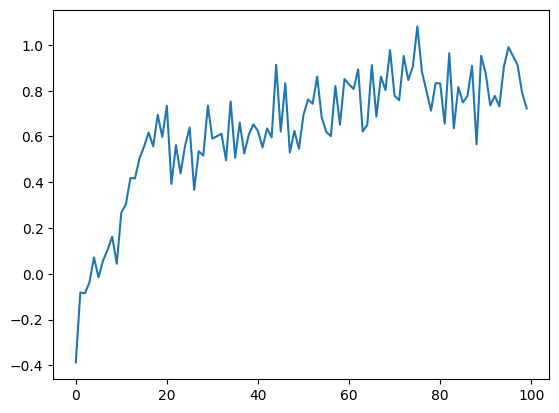

Test:
Algo reward: 1.6482789177033916 Buy-and-hold: 1.0914800968647447
Algo reward: 1.6622952200122447 Buy-and-hold: 1.1414374925595137
Algo reward: 1.8247104552575486 Buy-and-hold: 1.2485741340460443
Algo reward: 1.6096504464029637 Buy-and-hold: 1.0927947820949244
Algo reward: 1.729612899484678 Buy-and-hold: 1.1821032410983412
Algo reward: 1.8139241509057897 Buy-and-hold: 1.2326217613789616
Algo reward: 1.6998603868168676 Buy-and-hold: 1.2081403661412402
Algo reward: 1.5536518053680302 Buy-and-hold: 1.0289827095233894
Algo reward: 1.6948200019669566 Buy-and-hold: 1.1536815922494694
Algo reward: 1.7571569933218114 Buy-and-hold: 1.1738726329695246


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

import multiprocessing
from multiprocessing import Pool

import gymnasium as gym
import sys

# global variable for prices
prices = pd.read_csv('spy.csv', index_col='Date')['Close'].to_numpy()
cfg = RiskControlConfig()

# Fit normalizer on first 70% of data (train split)
n_train = int(0.5 * len(prices))
prices_train = prices[:n_train]
prices_test = prices[n_train:]
normalizer = fit_normalizer_from_prices(
    prices=prices_train,
    cfg=cfg,
    clip=5.0,
)


def make_env(prices, seed=None):
  env = RiskControlEnv(
    prices, config=cfg, normalizer=normalizer, episode_length=2000, seed=None)
  env = gym.wrappers.RecordEpisodeStatistics(env)

  # To get reproducible sampling of actions, a seed can be set with env.action_space.seed(123)
  if seed is not None:
    env.action_space.seed(seed)
  return env


### neural network

# hyperparameters
env = make_env(prices_train)
D = np.prod(env.observation_space.shape)
M = 128
K = env.action_space.shape[0]
action_max = env.action_space.high[0]

def relu(x):
  return x * (x > 0)

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

class ANN:
  def __init__(self, D, M, K, f=relu):
    self.D = D
    self.M = M
    self.K = K
    self.f = f

  def init(self):
    D, M, K = self.D, self.M, self.K
    self.W1 = np.random.randn(D, M) / np.sqrt(D)
    self.b1 = np.zeros(M)
    self.W2 = np.random.randn(M, K) / np.sqrt(M)
    self.b2 = np.zeros(K)

  def forward(self, X):
    Z = self.f(X @ self.W1 + self.b1)
    return sigmoid(Z @ self.W2 + self.b2) * action_max

  def sample_action(self, x):
    # assume input is a single state of size (D,)
    # first make it (N, D) to fit ML conventions
    X = np.atleast_2d(x)
    Y = self.forward(X)
    return Y[0] # first row

  def get_params(self):
    # return a flat array of parameters
    return np.concatenate([self.W1.flatten(), self.b1, self.W2.flatten(), self.b2])

  def get_params_dict(self):
    return {
      'W1': self.W1,
      'b1': self.b1,
      'W2': self.W2,
      'b2': self.b2,
    }

  def set_params(self, params):
    # params is a flat list
    # unflatten into individual weights
    D, M, K = self.D, self.M, self.K
    self.W1 = params[:D * M].reshape(D, M)
    self.b1 = params[D * M: D * M + M]
    self.W2 = params[D * M + M: D * M + M + M * K].reshape(M, K)
    self.b2 = params[-K:]


class OnlineStandardScaler:
  def __init__(self, num_inputs):
    self.n = 0
    self.mean = np.zeros(num_inputs)
    self.ssd = np.zeros(num_inputs)

  def partial_fit(self, X):
    self.n += 1
    delta = X - self.mean
    self.mean += delta / self.n
    delta2 = X - self.mean
    self.ssd += delta * delta2

  def transform(self, X):
    m = self.mean
    v = (self.ssd / self.n).clip(min=1e-2)
    s = np.sqrt(v)
    return (X - m) / s


scaler = OnlineStandardScaler(D)

class Adam:
  def __init__(self, params, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    self.lr = lr
    self.m = 0 # first moment
    self.v = 0 # second moment
    self.b1 = beta1
    self.b2 = beta2
    self.eps = eps
    self.t = 1 # time step
    self.params = params

  def update(self, g):
    # new m
    self.m = self.b1 * self.m + (1 - self.b1) * g
    # new v
    self.v = self.b2 * self.v + (1 - self.b2) * g**2
    # bias correction
    m_hat = self.m / (1 - self.b1**self.t)
    v_hat = self.v / (1 - self.b2**self.t)
    # update time step
    self.t += 1
    # update params
    self.params += self.lr * m_hat / (np.sqrt(v_hat) + self.eps)
    return self.params


def evolution_strategy(
  f,
  population_size,
  sigma,
  lr,
  initial_params,
  num_iters,
  pool,
  ):

  # assume initial params is a 1-D array
  num_params = len(initial_params)
  reward_per_iteration = np.zeros(num_iters)

  # create optimizer
  params = initial_params
  adam = Adam(params, lr)

  for t in range(num_iters):
    t0 = datetime.now()
    eps = np.random.randn(population_size, num_params)

    ### slow way
    R = np.zeros(population_size)
    for i in range(population_size):
      R[i] = f(params + sigma * eps[i])

    ### fast way
    # R = pool.map(f, [params + sigma * eps[i] for i in range(population_size)])
    # R = np.array(R)

    m = R.mean()
    s = R.std()
    if s == 0:
      # we can't apply the following equation
      print("Skipping")
      continue

    A = (R - m) / s
    reward_per_iteration[t] = m
    g = eps.T @ A / (population_size * sigma)
    params = adam.update(g)

    print("Iter:", t, "Avg Reward:", m, "Max Reward:", R.max(), "Duration:", datetime.now() - t0)

    # test
    if t > 0 and t % 10 == 0:
      f(params, test=True)


  return params, reward_per_iteration


def reward_function(params, test=False):
  # run one episode of env w/ params
  model = ANN(D, M, K)
  model.set_params(params)

  if test:
    env = make_env(prices_test)
  else:
    env = make_env(prices_train)

  # play one episode and return total reward
  episode_reward = 0
  episode_length = 0
  done = False
  state, _ = env.reset()
  while not done:
    scaler.partial_fit(state)
    state = scaler.transform(state)

    # get action
    action = model.sample_action(state)

    # perform action
    state, reward, done, truncated, info = env.step(action)
    done = done or truncated

    # update total reward and length
    episode_reward += reward
    episode_length += 1

  # close env
  env.close()

  assert(info['episode']['r'] == episode_reward)

  if test:
    # print(info)
    print("Algo reward:", episode_reward, "Buy-and-hold:", info['buy_and_hold'])

  return episode_reward


if __name__ == '__main__':

  # create model
  model = ANN(D, M, K)

  if len(sys.argv) > 1 and sys.argv[1] == 'play':
    # play with a saved model
    j = np.load('es_model.npz')
    best_params = np.concatenate([j['W1'].flatten(), j['b1'], j['W2'].flatten(), j['b2']])

    # in case initial shapes are not correct
    # D, M = j['W1'].shape
    # K = len(j['b2'])
    # model.D, model.M, model.K = D, M, K
  else:
    # pool for parallel evaluation
    pool = Pool(4)

    # train and save model
    model.init()
    params = model.get_params()
    best_params, rewards = evolution_strategy(
      f=reward_function,
      population_size=30,
      sigma=0.05,
      lr=0.02,
      initial_params=params,
      num_iters=100,
      pool=pool,
    )

    # plot the rewards per iteration
    plt.plot(rewards)
    plt.show()

    # save params
    model.set_params(best_params)
    np.savez(
      'es_model.npz',
      train=rewards,
      **model.get_params_dict(),
    )

  # play with saved model / test episode
  print("Test:")
  for _ in range(10):
    reward_function(best_params, test=True)

![](https://deeplearningcourses.com/notebooks_v3_pxl?sc=ajMgus4HVOdGR3CZkAAu7w&n=ES+Trader)